In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime

In [5]:
file_name = "../data/delays/subway/cleaned_data/cleaned_subway_data.csv"

sub_data = pd.read_csv(file_name)

In [6]:
sub_data["Time"] = pd.to_datetime(sub_data["Datetime"]).dt.strftime('%H:%M:%S')

In [7]:
sub_data["10_min_time"] = pd.to_datetime(sub_data["Time"])
sub_data["10_min_time"] = sub_data["10_min_time"].dt.floor("10T")
sub_data["date_only"] = pd.to_datetime(sub_data["Time"])
sub_data["date_only"] = sub_data["date_only"].dt.floor("1D")
sub_data_copy = sub_data

# drop outliers (display these later)
super_delays = sub_data[sub_data["Min Delay"]>60].dropna()
super_delays = super_delays[super_delays["Min Delay"]<1000]
sub_data = sub_data[sub_data["Min Delay"]<=60] 

mean_sub_data = sub_data.groupby("10_min_time")[["Min Delay", "Min Gap"]].mean().reset_index()
super_means = super_delays.groupby("10_min_time")[["Min Delay", "Min Gap"]].mean().reset_index()

/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54604/239684951.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sub_data["10_min_time"] = pd.to_datetime(sub_data["Time"])
/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54604/239684951.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sub_data["10_min_time"] = sub_data["10_min_time"].dt.floor("10T")
/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54604/239684951.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sub_data["date_only"] = pd.to_datetime(sub_data["Time"])


In [8]:
time = mean_sub_data["10_min_time"].dt.strftime("%I:%M %p")
time_ticks  = time[::12]
delay = mean_sub_data["Min Delay"]
gap = mean_sub_data["Min Gap"]
super_time = super_means["10_min_time"].dt.strftime("%I:%M %p")
super_delay = super_means["Min Delay"]
super_gap = super_means["Min Gap"]

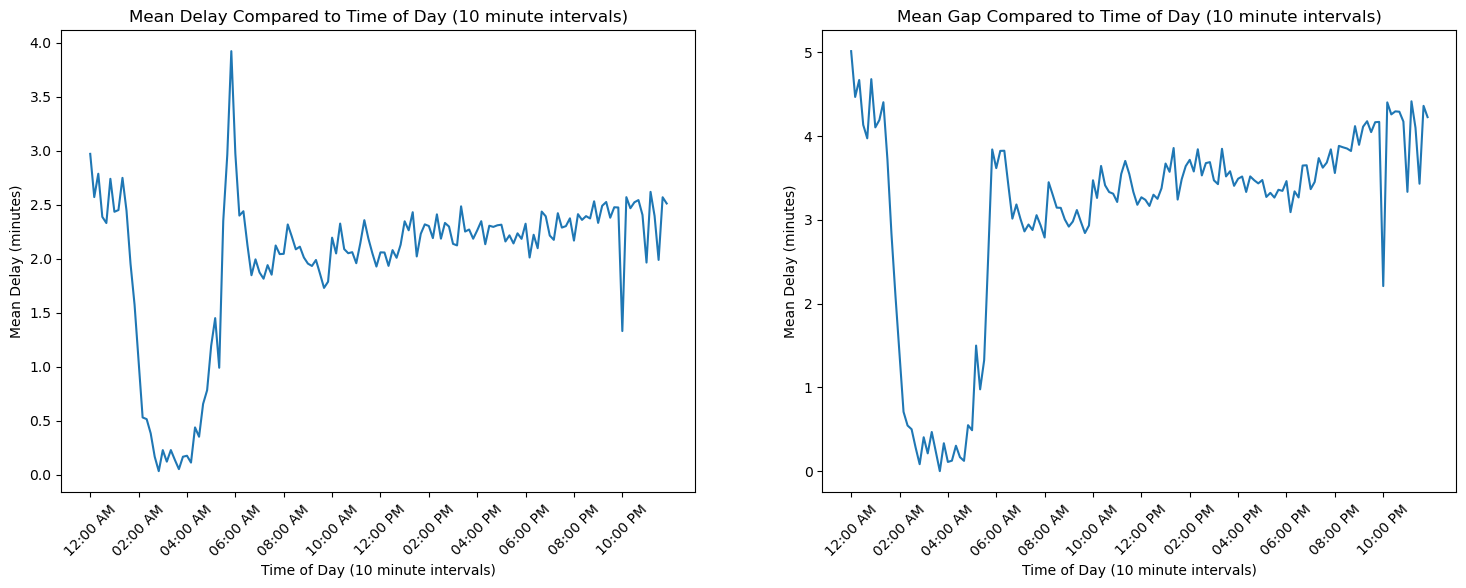

In [9]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].plot(time, delay, linestyle='-')
axes[0].set_title("Mean Delay Compared to Time of Day (10 minute intervals)")
axes[0].set_xlabel("Time of Day (10 minute intervals)")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].set_xticks(time_ticks)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(time, gap, linestyle='-')
axes[1].set_title("Mean Gap Compared to Time of Day (10 minute intervals)")
axes[1].set_xlabel("Time of Day (10 minute intervals)")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].set_xticks(time_ticks)
axes[1].tick_params(axis='x', rotation=45)

## Analysis for super delays (>60 mins)

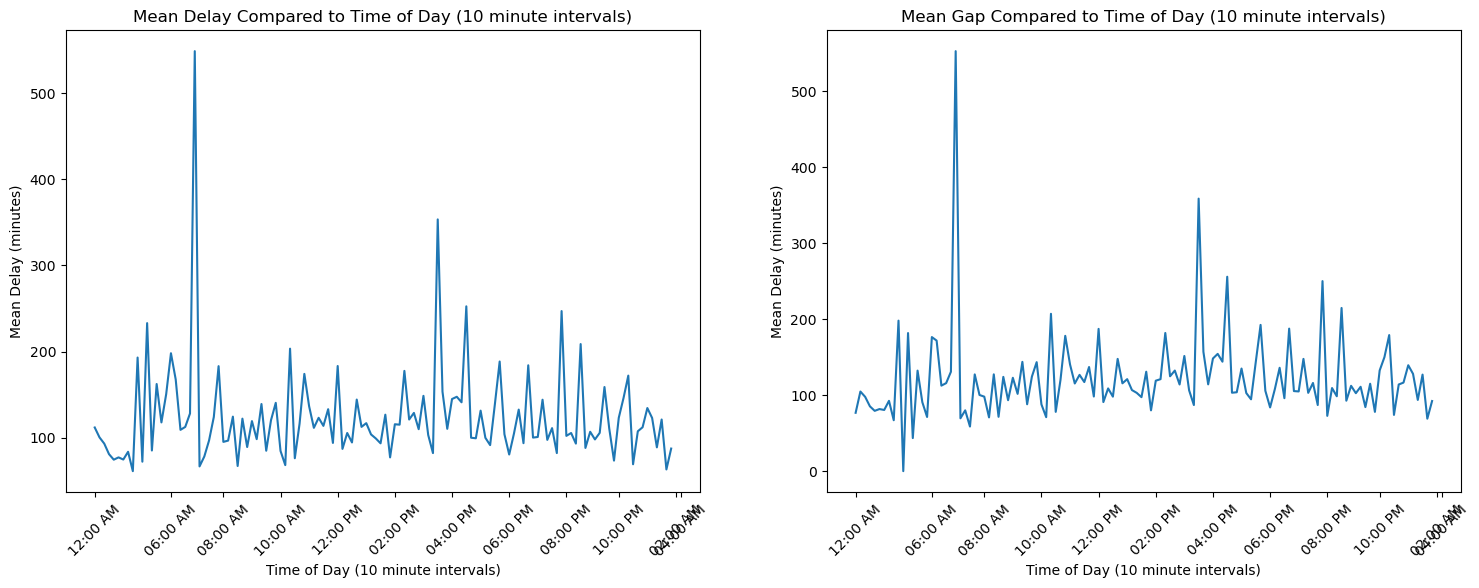

In [10]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].plot(super_time, super_delay, linestyle='-')
axes[0].set_title("Mean Delay Compared to Time of Day (10 minute intervals)")
axes[0].set_xlabel("Time of Day (10 minute intervals)")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].set_xticks(time_ticks)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(super_time, super_gap, linestyle='-')
axes[1].set_title("Mean Gap Compared to Time of Day (10 minute intervals)")
axes[1].set_xlabel("Time of Day (10 minute intervals)")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].set_xticks(time_ticks)
axes[1].tick_params(axis='x', rotation=45)

## Without removing outliers

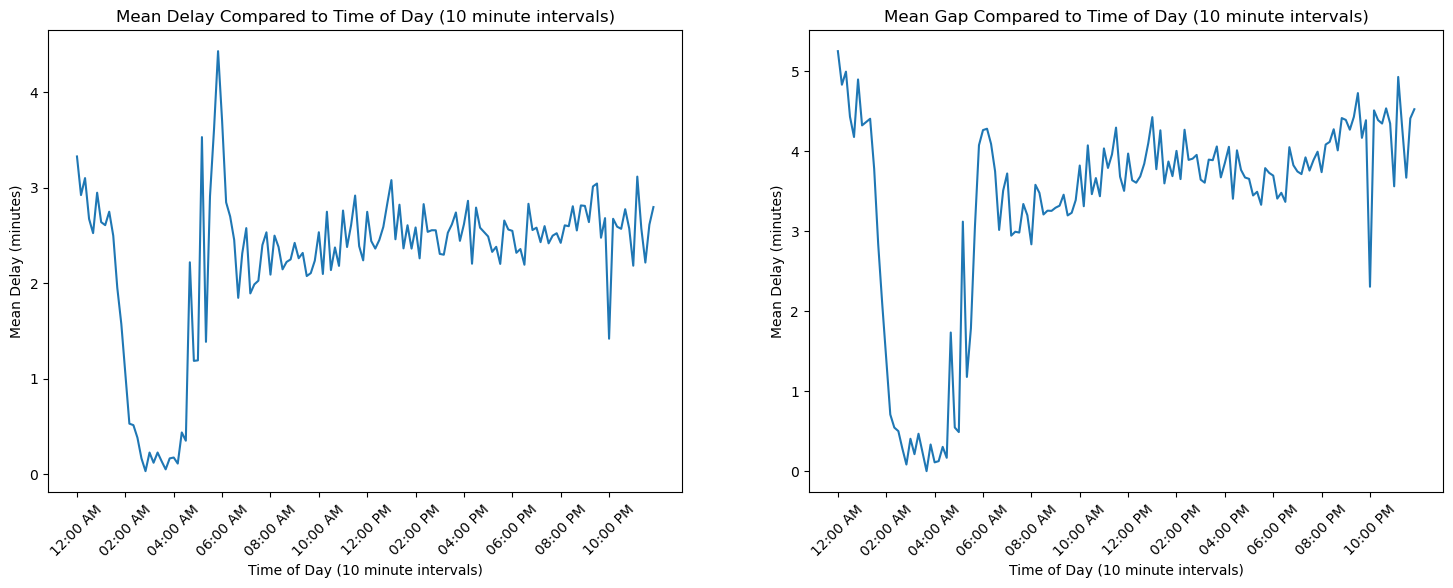

In [11]:
mean_sub_data = sub_data_copy.groupby("10_min_time")[["Min Delay", "Min Gap"]].mean().reset_index()
time = mean_sub_data["10_min_time"].dt.strftime("%I:%M %p")
time_ticks  = time[::12]
delay = mean_sub_data["Min Delay"]
gap = mean_sub_data["Min Gap"]

fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].plot(time, delay, linestyle='-')
axes[0].set_title("Mean Delay Compared to Time of Day (10 minute intervals)")
axes[0].set_xlabel("Time of Day (10 minute intervals)")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].set_xticks(time_ticks)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(time, gap, linestyle='-')
axes[1].set_title("Mean Gap Compared to Time of Day (10 minute intervals)")
axes[1].set_xlabel("Time of Day (10 minute intervals)")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].set_xticks(time_ticks)
axes[1].tick_params(axis='x', rotation=45)

## By day of the week

,Day,Min Delay,Min Gap
1,Monday,2.167999,3.307489
5,Tuesday,2.154371,3.266962
6,Wednesday,2.151202,3.262704
4,Thursday,2.180723,3.299170
0,Friday,2.219148,3.404230
2,Saturday,2.285782,3.746341
3,Sunday,2.310300,3.783745


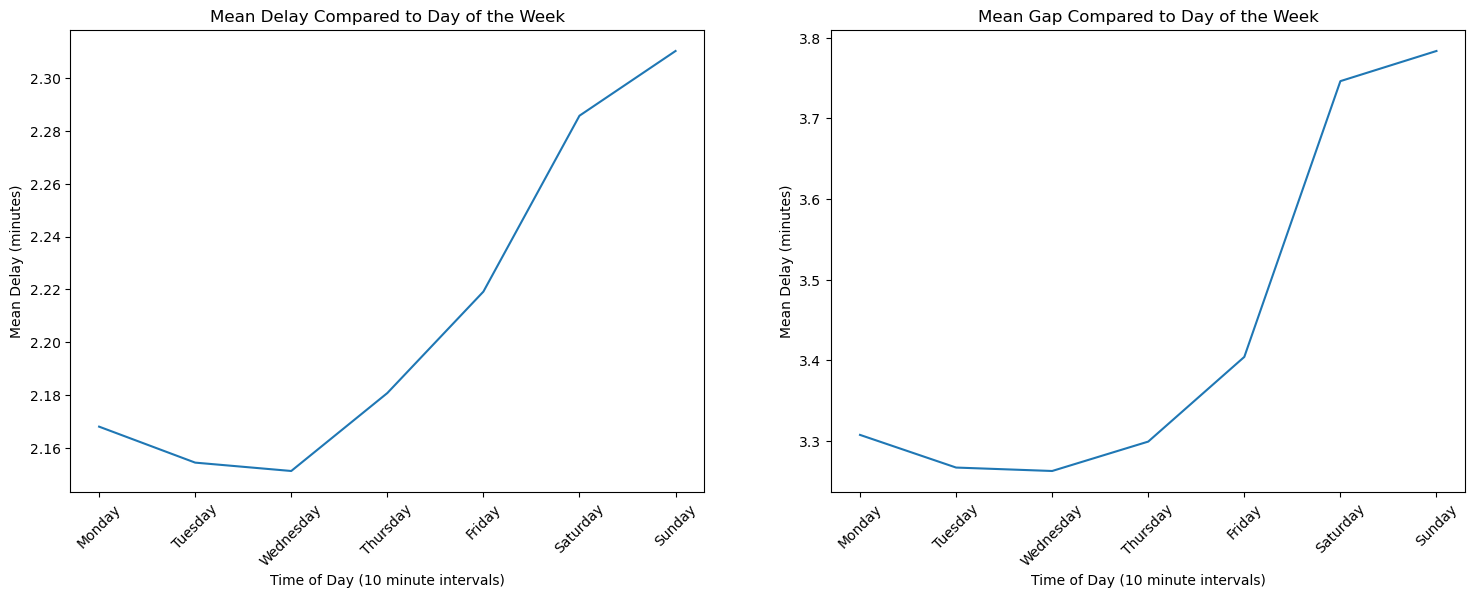

In [12]:
new_data  = sub_data_copy[sub_data_copy["Min Delay"]<=60]

mean_sub_data = new_data.groupby("Day")[["Min Delay", "Min Gap"]].mean().reset_index()
mean_sub_data = mean_sub_data.reindex([1, 5, 6, 4, 0, 2, 3])
time = mean_sub_data["Day"]
delay = mean_sub_data["Min Delay"]
gap = mean_sub_data["Min Gap"]

display(mean_sub_data)

fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].plot(time, delay, linestyle='-')
axes[0].set_title("Mean Delay Compared to Day of the Week")
axes[0].set_xlabel("Time of Day (10 minute intervals)")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(time, gap, linestyle='-')
axes[1].set_title("Mean Gap Compared to Day of the Week")
axes[1].set_xlabel("Time of Day (10 minute intervals)")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].tick_params(axis='x', rotation=45)

,Day,Min Delay,Min Gap
1,Monday,117.064103,117.102564
5,Tuesday,136.518072,127.975904
6,Wednesday,113.606557,117.524590
4,Thursday,141.151515,140.712121
0,Friday,117.626866,114.447761
2,Saturday,124.561404,121.526316
3,Sunday,106.608696,101.971014


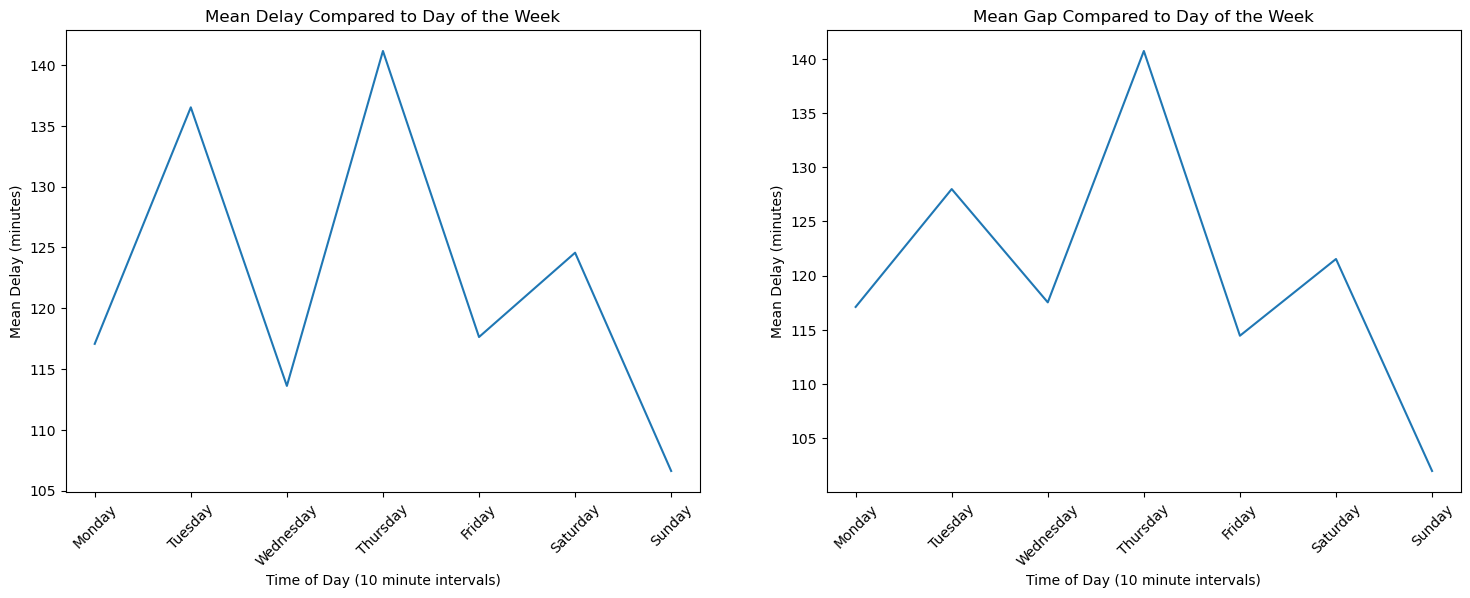

In [13]:
new_data  = sub_data_copy[sub_data_copy["Min Delay"]>60]

mean_sub_data = new_data.groupby("Day")[["Min Delay", "Min Gap"]].mean().reset_index()
mean_sub_data = mean_sub_data.reindex([1, 5, 6, 4, 0, 2, 3])
time = mean_sub_data["Day"]
delay = mean_sub_data["Min Delay"]
gap = mean_sub_data["Min Gap"]

display(mean_sub_data)

fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].plot(time, delay, linestyle='-')
axes[0].set_title("Mean Delay Compared to Day of the Week")
axes[0].set_xlabel("Time of Day (10 minute intervals)")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(time, gap, linestyle='-')
axes[1].set_title("Mean Gap Compared to Day of the Week")
axes[1].set_xlabel("Time of Day (10 minute intervals)")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].tick_params(axis='x', rotation=45)

## Analysis by Day of Week and Time

In [14]:
sub_data = pd.read_csv(file_name)
sub_data["Time"] = pd.to_datetime(sub_data["Datetime"]).dt.strftime('%H:%M:%S')

sub_data["10_min_time"] = pd.to_datetime(sub_data["Time"])
sub_data["10_min_time"] = sub_data["10_min_time"].dt.floor("10T")
sub_data_copy = sub_data

# drop outliers (display these later)
super_delays = sub_data[sub_data["Min Delay"]>60].dropna()
super_delays = super_delays[super_delays["Min Delay"]<1000]
sub_data = sub_data[sub_data["Min Delay"]<=60] 

mean_sub_data = sub_data.groupby(["Day","10_min_time"])[["Min Delay", "Min Gap"]].mean().reset_index()
super_means = super_delays.groupby(["Day","10_min_time"])[["Min Delay", "Min Gap"]].mean().reset_index()

display(mean_sub_data)

/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54604/1937997676.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sub_data["10_min_time"] = pd.to_datetime(sub_data["Time"])
/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54604/1937997676.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sub_data["10_min_time"] = sub_data["10_min_time"].dt.floor("10T")


,Day,10_min_time,Min Delay,Min Gap
0,Friday,2025-04-03 00:00:00,3.266667,5.608889
1,Friday,2025-04-03 00:10:00,2.786164,4.528302
2,Friday,2025-04-03 00:20:00,2.450867,4.086705
3,Friday,2025-04-03 00:30:00,2.502857,4.394286
4,Friday,2025-04-03 00:40:00,2.836478,4.433962
...,...,...,...,...
1003,Wednesday,2025-04-03 23:10:00,2.362385,4.027523
1004,Wednesday,2025-04-03 23:20:00,2.364865,4.027027
1005,Wednesday,2025-04-03 23:30:00,1.908367,3.366534
1006,Wednesday,2025-04-03 23:40:00,2.196429,3.577381


In [15]:
delay = {}
time = {}
gap = {}
for day in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]:
    time[day] = mean_sub_data.loc[mean_sub_data["Day"] == day]["10_min_time"].dt.strftime("%I:%M %p")
    delay[day] = mean_sub_data.loc[mean_sub_data["Day"] == day]["Min Delay"].values
    gap[day] = mean_sub_data.loc[mean_sub_data["Day"] == day]["Min Gap"].values
time_ticks = time["Monday"][::12]
super_time = super_means["10_min_time"].dt.strftime("%I:%M %p")
super_delay = super_means["Min Delay"]
super_gap = super_means["Min Gap"]

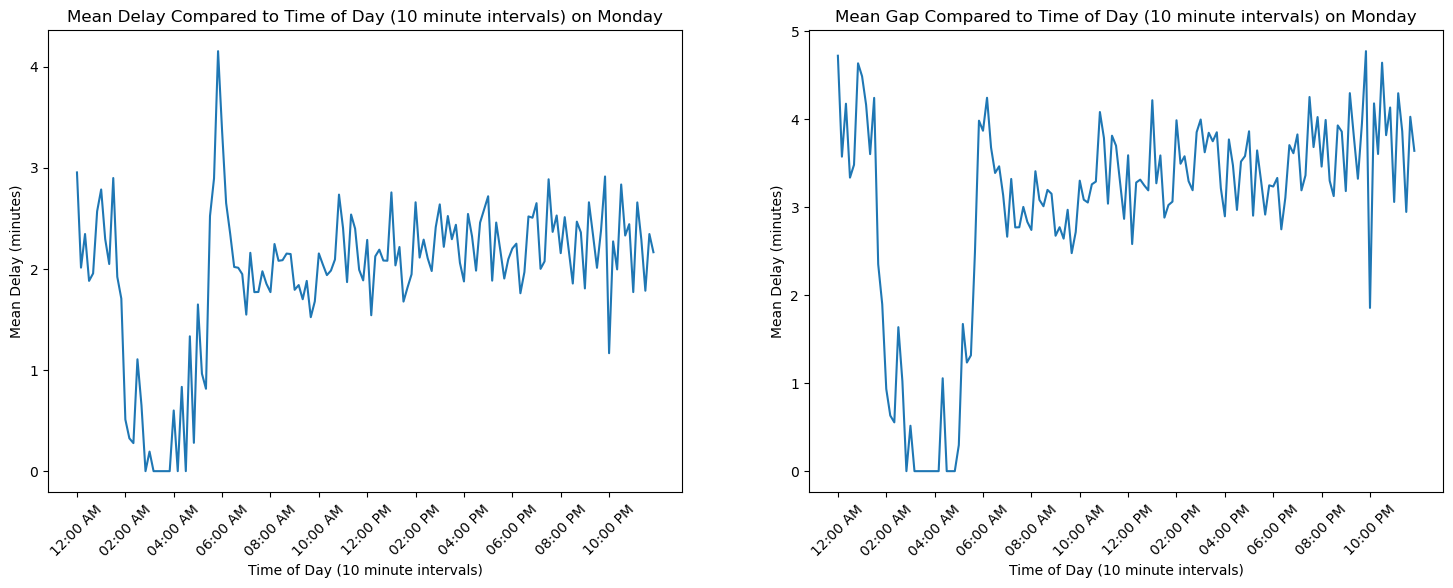

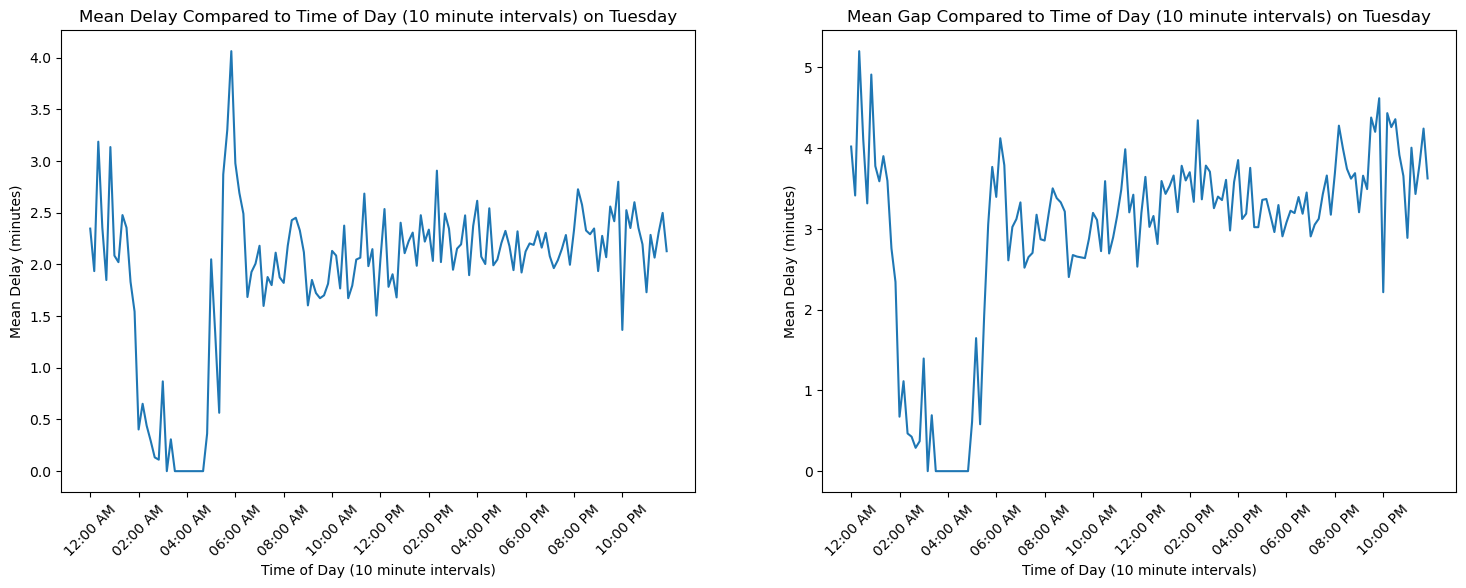

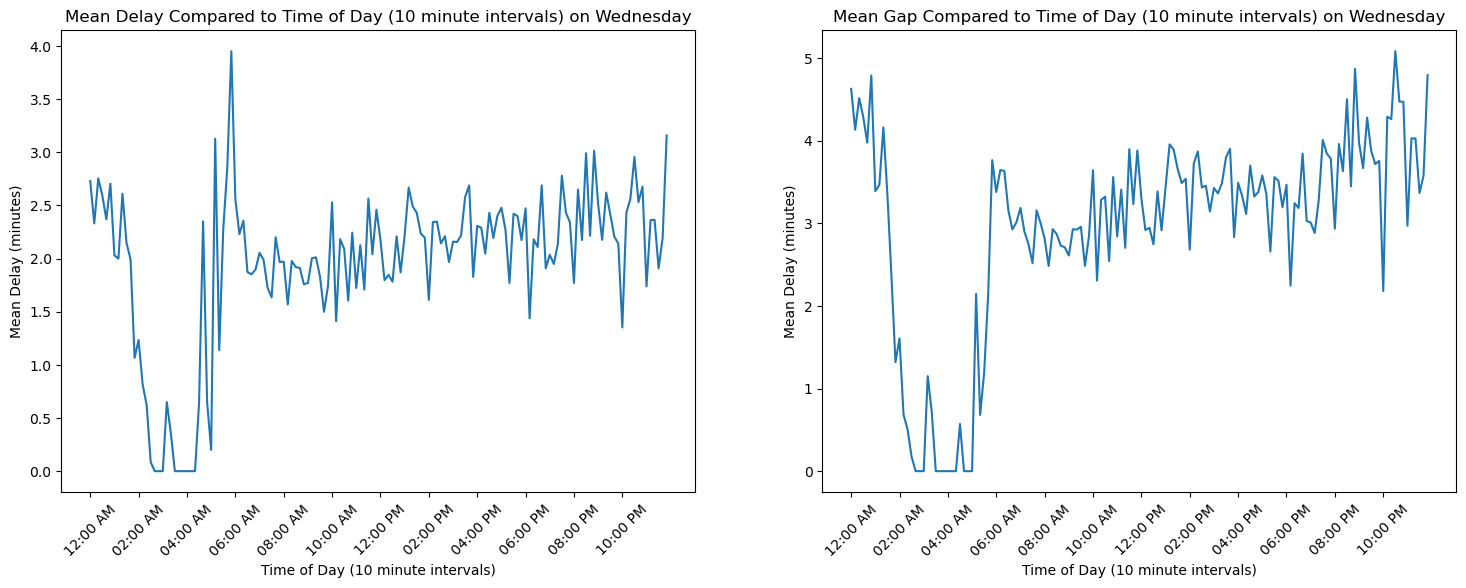

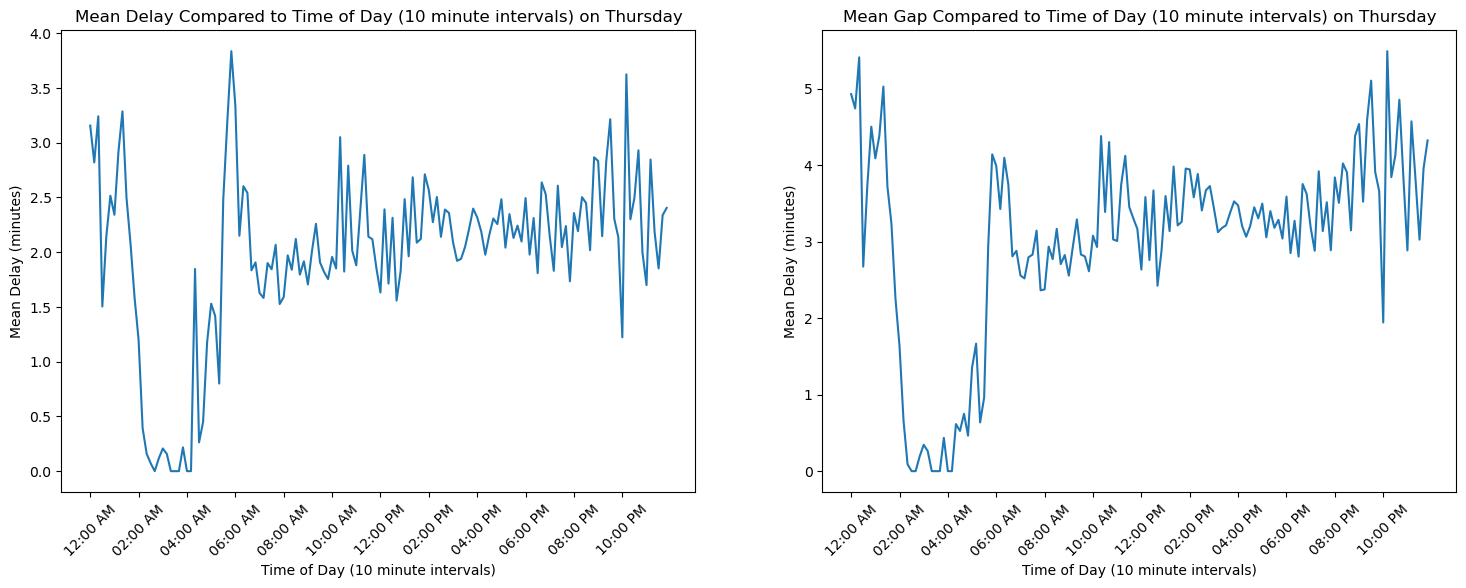

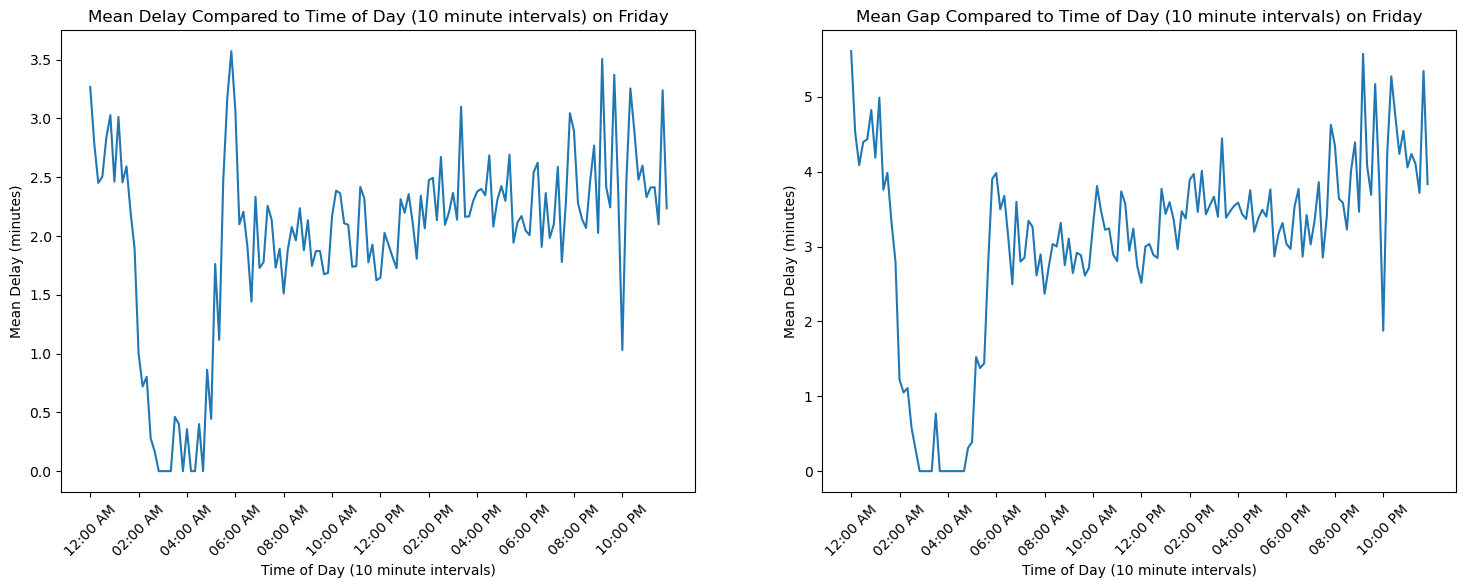

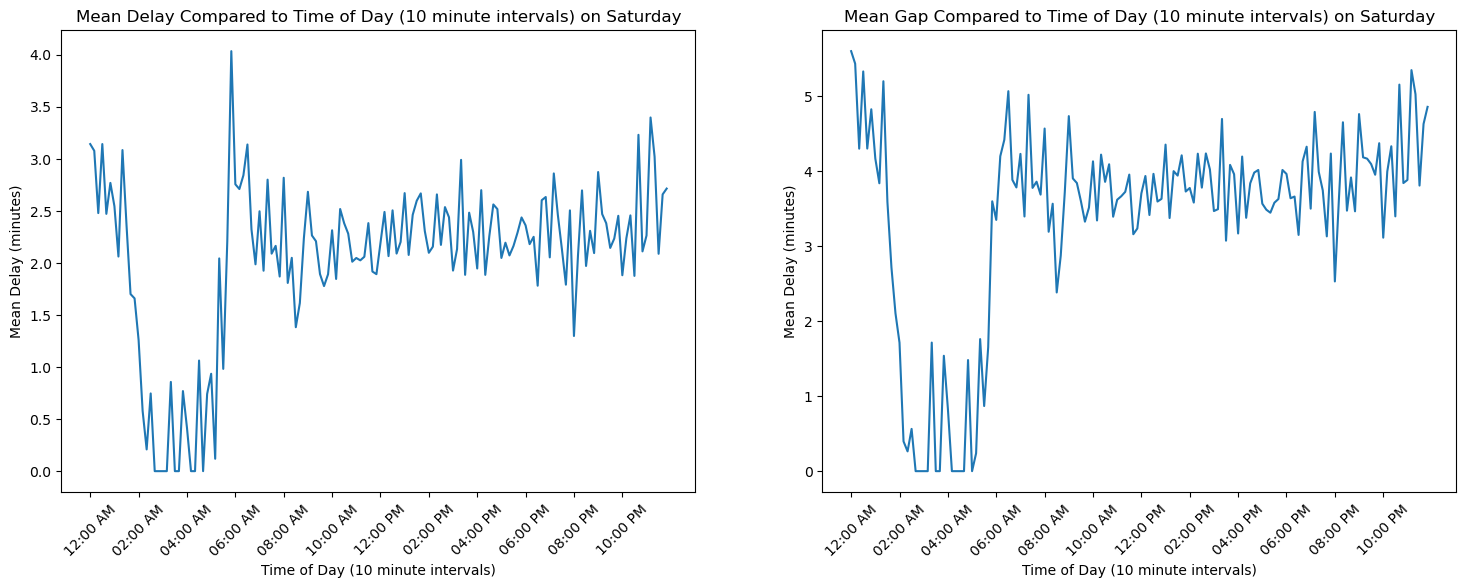

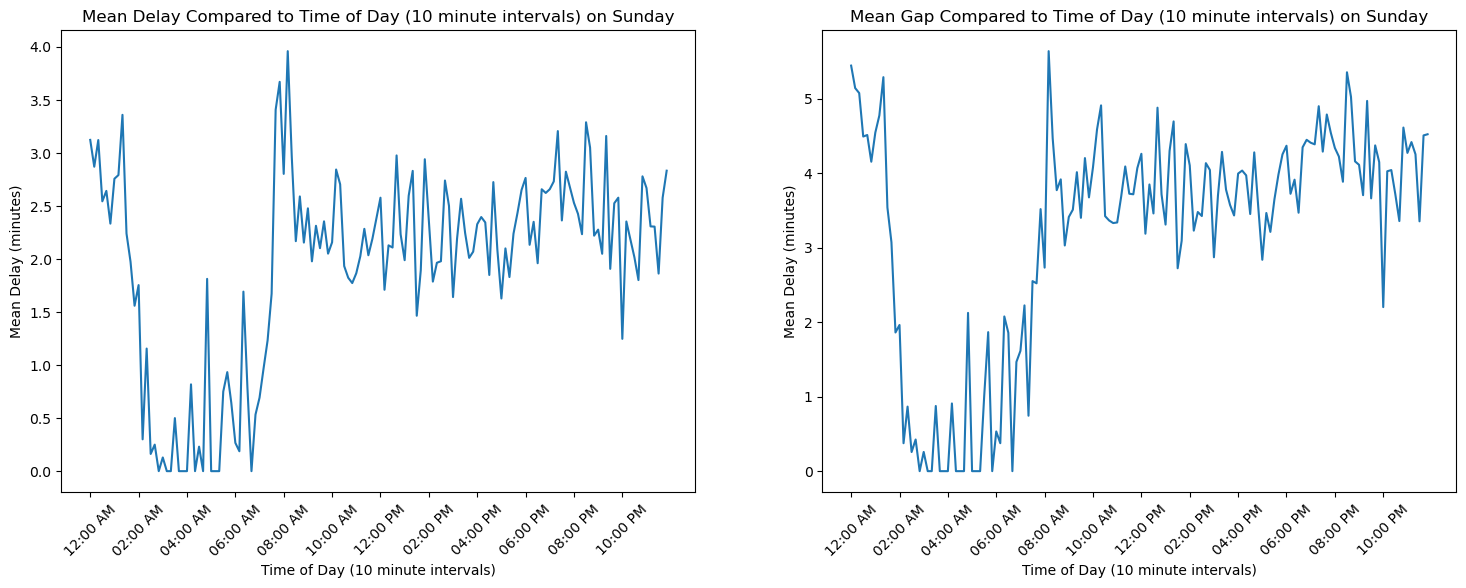

In [16]:
for day in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]:
    fig, axes = plt.subplots(1, 2, figsize = (18, 6))

    axes[0].set_title(f"Mean Delay Compared to Time of Day (10 minute intervals) on {day}")
    axes[0].set_xlabel("Time of Day (10 minute intervals)")
    axes[0].set_ylabel("Mean Delay (minutes)")
    axes[0].plot(time[day], delay[day], linestyle='-')
    axes[0].set_xticks(time_ticks)
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].plot(time[day], gap[day], linestyle='-')
    axes[1].set_title(f"Mean Gap Compared to Time of Day (10 minute intervals) on {day}")
    axes[1].set_xlabel("Time of Day (10 minute intervals)")
    axes[1].set_ylabel("Mean Delay (minutes)")
    axes[1].set_xticks(time_ticks)
    axes[1].tick_params(axis='x', rotation=45)
    plt.savefig(f"../data/delays/subway/results/time_delays_{day}.png")
    plt.show()

In [17]:
sub_data = sub_data_copy
dates = sub_data["Datetime"]
sub_data["30_day"] = pd.to_datetime(sub_data["Datetime"])
sub_data["30_day"] = sub_data["30_day"].dt.floor("30D")
sub_data = sub_data[sub_data["Min Delay"]<=60] 
sub_data = sub_data[sub_data["30_day"]<=pd.Timestamp("2025-01-01")] 

mean_sub_data = sub_data.groupby("30_day")[["Min Delay", "Min Gap"]].mean().reset_index()


In [18]:
time = mean_sub_data["30_day"]
time_ticks  = time[::12]
delay = mean_sub_data["Min Delay"]
gap = mean_sub_data["Min Gap"]

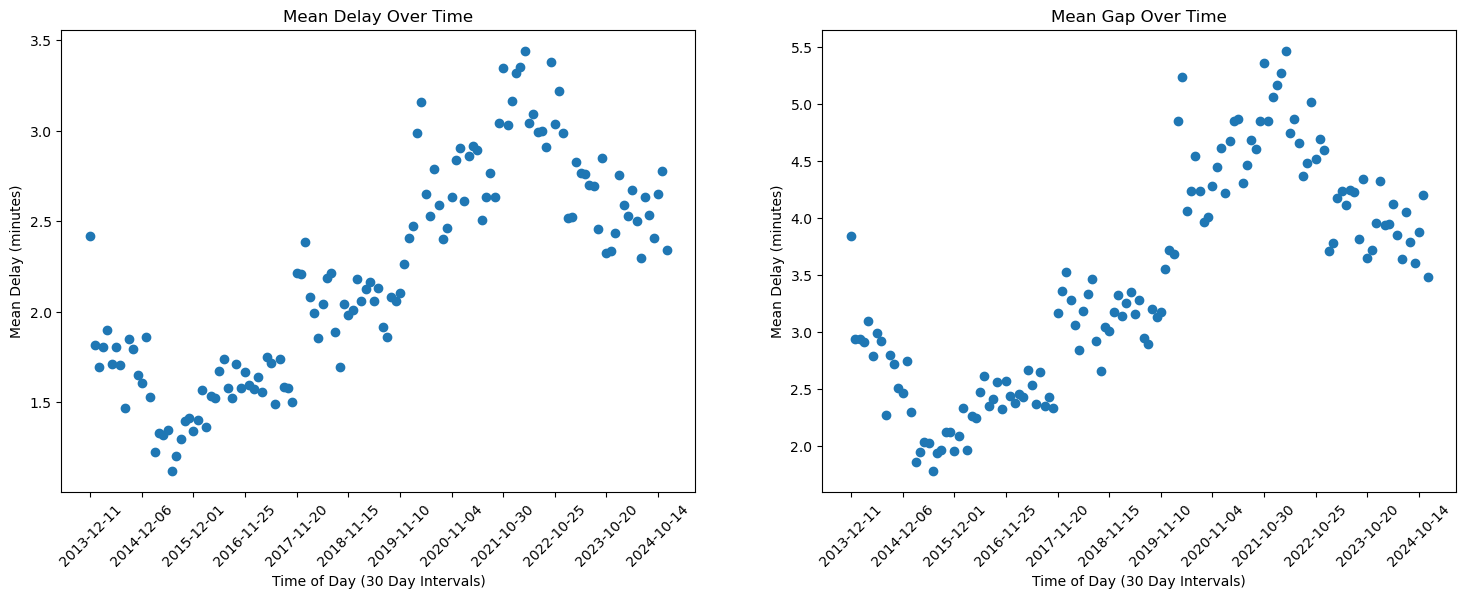

In [19]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(time, delay, marker='o')
axes[0].set_title("Mean Delay Over Time")
axes[0].set_xlabel("Time of Day (30 Day Intervals)")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].set_xticks(time_ticks)
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(time, gap,  marker='o')
axes[1].set_title("Mean Gap Over Time")
axes[1].set_xlabel("Time of Day (30 Day Intervals)")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].set_xticks(time_ticks)
axes[1].tick_params(axis='x', rotation=45)

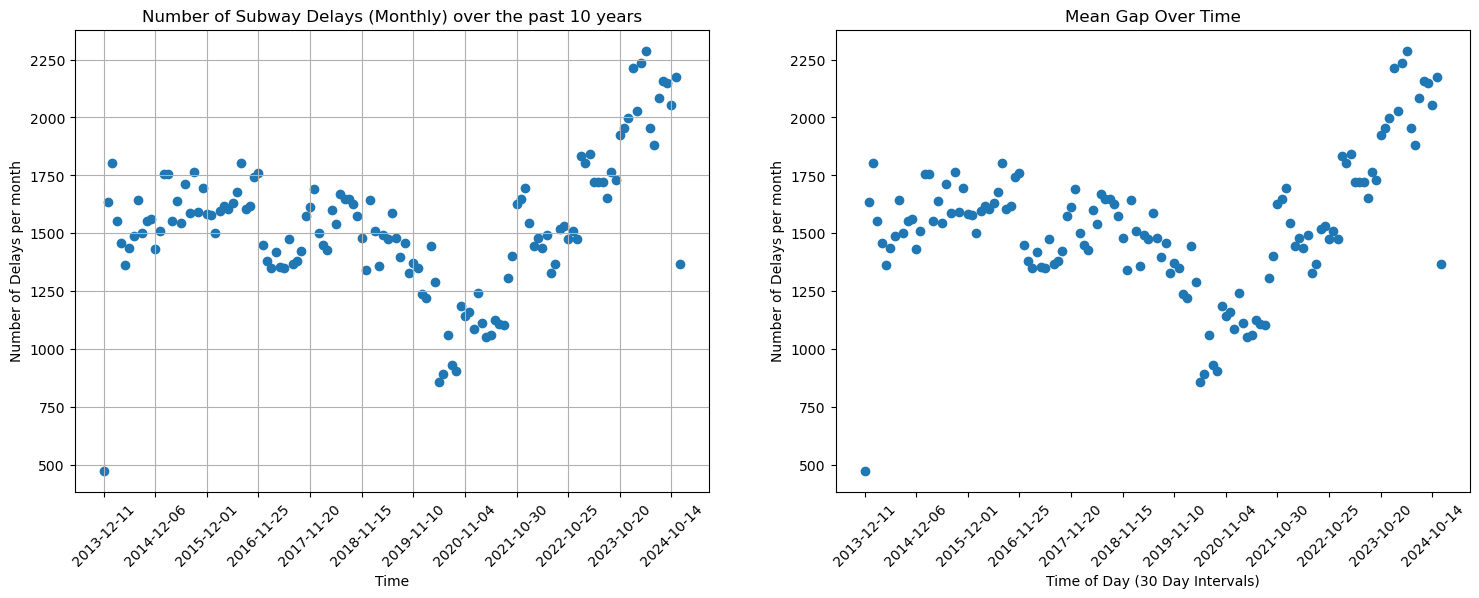

In [22]:
count_sub_data = sub_data.groupby("30_day")[["Min Delay", "Min Gap"]].count().reset_index()

time = count_sub_data["30_day"]
time_ticks  = time[::12]
delay = count_sub_data["Min Delay"]
gap = count_sub_data["Min Gap"]

fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(time, delay, marker='o')
axes[0].set_title("Number of Subway Delays (Monthly) over the past 10 years")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Number of Delays per month")
axes[0].set_xticks(time_ticks)
axes[0].grid()
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(time, gap,  marker='o')
axes[1].set_title("Mean Gap Over Time")
axes[1].set_xlabel("Time of Day (30 Day Intervals)")
axes[1].set_ylabel("Number of Delays per month")
axes[1].set_xticks(time_ticks)
axes[1].tick_params(axis='x', rotation=45)

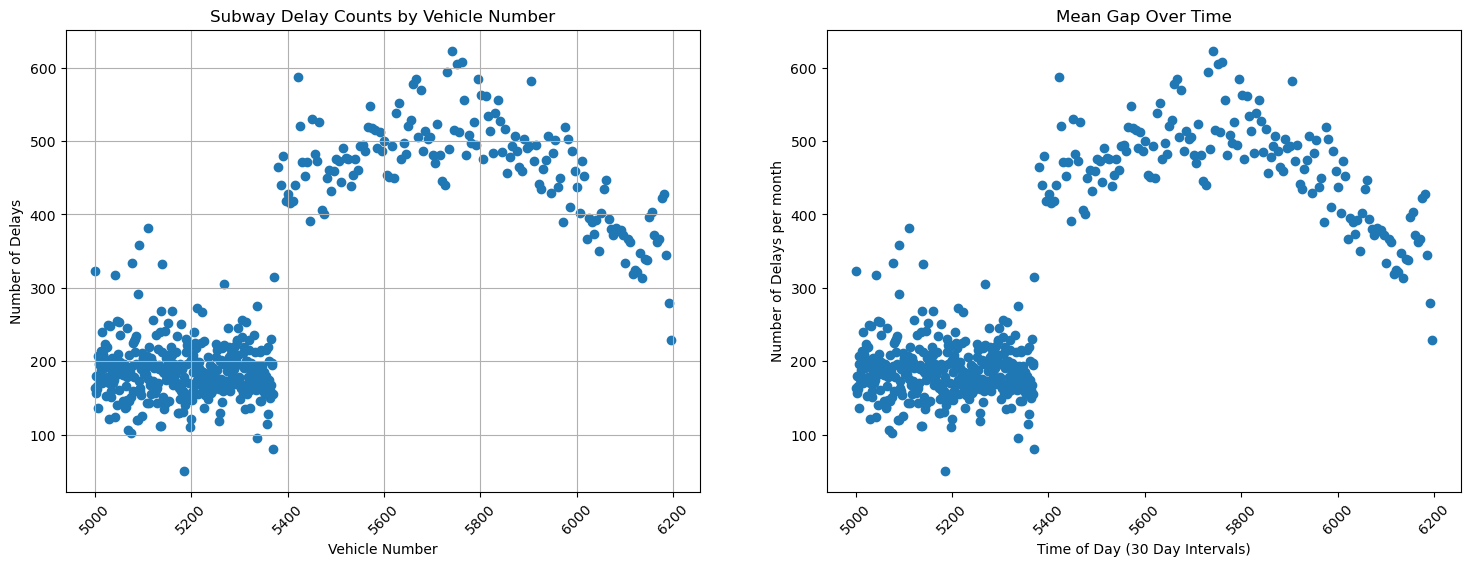

In [28]:
vehicle_sub_data = sub_data.groupby("Vehicle")[["Min Delay", "Min Gap"]].count().reset_index()
vehicle_sub_data = vehicle_sub_data[vehicle_sub_data["Vehicle"]  > 0]
vehicle_sub_data = vehicle_sub_data[vehicle_sub_data["Vehicle"]  < 10000]
vehicle_sub_data = vehicle_sub_data[vehicle_sub_data["Min Delay"]  > 15]
time = vehicle_sub_data["Vehicle"]
time_ticks  = time[::12]
delay = vehicle_sub_data["Min Delay"]
gap = vehicle_sub_data["Min Gap"]

fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(time, delay, marker='o')
axes[0].set_title("Subway Delay Counts by Vehicle Number")
axes[0].set_xlabel("Vehicle Number")
axes[0].set_ylabel("Number of Delays")
# axes[0].set_xticks(time_ticks)
axes[0].grid()
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(time, gap,  marker='o')
axes[1].set_title("Mean Gap Over Time")
axes[1].set_xlabel("Time of Day (30 Day Intervals)")
axes[1].set_ylabel("Number of Delays per month")
# axes[1].set_xticks(time_ticks)
axes[1].tick_params(axis='x', rotation=45)

# Baseline Model: Linear Regression for Delay Counts by Time, Day, and Station Name

In [21]:
count_sub_data = sub_data.groupby(["date_only","10_min_time", "Day","Station Name"])["Min Delay"].count().reset_index()
display(count_sub_data)

KeyError: 'date_only'

Linear Regression Imports

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Independent Variable Cleaning

In [ ]:
count_encoded = pd.get_dummies(count_sub_data, columns=['Day',"Station Name"], drop_first=True)
count_encoded['Time'] = count_encoded['10_min_time'].dt.hour * 60 +  count_encoded['10_min_time'].dt.minute


Get Dependent (Count of Delays) and Independent (Time, Station, Day) variables 

In [ ]:
X = count_encoded.drop(columns=["date_only",'Min Delay', '10_min_time']) 
y = count_encoded['Min Delay']

display(X)

,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,Station Name_BAY,Station Name_BAYVIEW,Station Name_BESSARION,Station Name_BLOOR,...,Station Name_VAUGHAN METROPOLITAN CENTRE,Station Name_VICTORIA PARK,Station Name_WARDEN,Station Name_WELLESLEY,Station Name_WILSON,Station Name_WOODBINE,Station Name_YORK MILLS,Station Name_YORK UNIVERSITY,Station Name_YORKDALE,Time
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
1,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,0
2,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,0
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,0
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52182,False,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,1430
52183,False,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,1430
52184,False,False,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,1430
52185,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,1430


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Text(0, 0.5, 'Predicted Test Output Values')

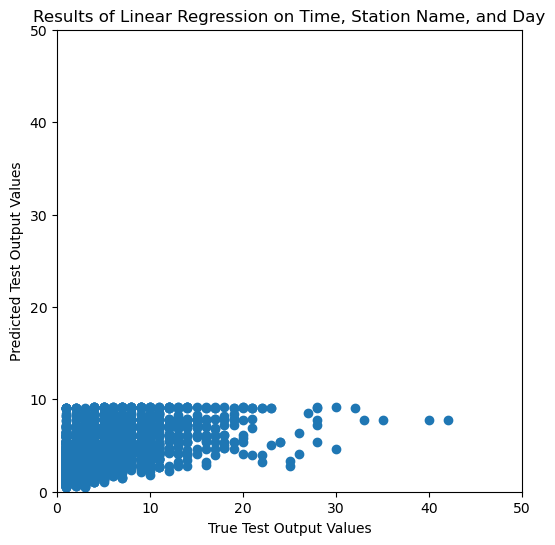

In [ ]:
fig, axes = plt.subplots(1, 1, figsize = (6, 6))

axes.scatter(y_test, y_pred, marker='o')
axes.set_title("Results of Linear Regression on Time, Station Name, and Day")
axes.set_xlim(0,50)
axes.set_ylim(0,50)
axes.set_xlabel("True Test Output Values")
axes.set_ylabel("Predicted Test Output Values")

## Without Station Name

In [ ]:
count_sub_data = sub_data.groupby(["date_only","10_min_time", "Day"])["Min Delay"].count().reset_index()
display(count_sub_data)

,date_only,10_min_time,Day,Min Delay
0,2025-03-26,2025-03-26 00:00:00,Friday,181
1,2025-03-26,2025-03-26 00:00:00,Monday,124
2,2025-03-26,2025-03-26 00:00:00,Saturday,117
3,2025-03-26,2025-03-26 00:00:00,Sunday,130
4,2025-03-26,2025-03-26 00:00:00,Thursday,120
...,...,...,...,...
1001,2025-03-26,2025-03-26 23:50:00,Saturday,142
1002,2025-03-26,2025-03-26 23:50:00,Sunday,114
1003,2025-03-26,2025-03-26 23:50:00,Thursday,135
1004,2025-03-26,2025-03-26 23:50:00,Tuesday,120


In [ ]:
count_encoded = pd.get_dummies(count_sub_data, columns=['Day'], drop_first=True)
count_encoded['Time'] = count_encoded['10_min_time'].dt.hour * 60 +  count_encoded['10_min_time'].dt.minute

In [ ]:
X = count_encoded.drop(columns=["date_only",'Min Delay', '10_min_time']) 
y = count_encoded['Min Delay']

display(X)

,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,Time
0,False,False,False,False,False,False,0
1,True,False,False,False,False,False,0
2,False,True,False,False,False,False,0
3,False,False,True,False,False,False,0
4,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...
1001,False,True,False,False,False,False,1430
1002,False,False,True,False,False,False,1430
1003,False,False,False,True,False,False,1430
1004,False,False,False,False,True,False,1430


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


Text(0, 0.5, 'Predicted Test Output Values')

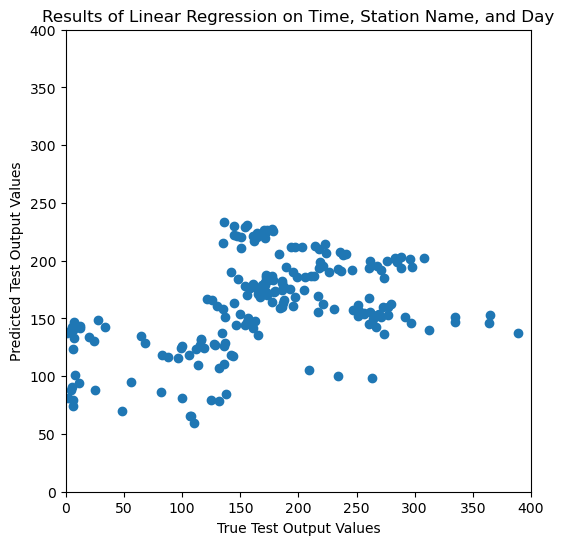

In [ ]:
fig, axes = plt.subplots(1, 1, figsize = (6, 6))

axes.scatter(y_test, y_pred, marker='o')
axes.set_title("Results of Linear Regression on Time, Station Name, and Day")
axes.set_xlim(0,400)
axes.set_ylim(0,400)
axes.set_xlabel("True Test Output Values")
axes.set_ylabel("Predicted Test Output Values")